# TDCRPy — Functional Validation Notebook

Compares **two user-chosen versions** of TDCRPy on a fixed set of nuclides.

- **Forward problem** (sections 1–7): given a fixed free parameter `L`, compute
  the resulting TDCR efficiencies with both the **analytical**
  (`modelAnalytical`) and **stochastic** (`TDCRPy`) models.
- **Inverse problem** (sections 8–9): given a fixed measured TDCR ratio `T/D`,
  recover `L` and the efficiencies with `effA()` (analytical) and `eff()`
  (stochastic) — the entry points a real TDCR measurement would use.

| Nuclide | Decay mode | Key physics exercised |
|---------|------------|----------------------|
| H-3     | Pure β⁻ (18.6 keV) | Low-energy quenching, pure beta path |
| Fe-55   | EC + Mn Kα X-rays (5.9 keV) | Atomic relaxation, Auger electrons |
| Co-60   | β⁻ + γ (1.17 / 1.33 MeV) | Photon interactions, photoelectric / pair production |
| Sr-90   | Pure β⁻ (0.546 MeV) | Medium-energy beta quenching |
| Cd-109  | EC + Ag-109m IT γ (88 keV, delayed) | Delayed coincidences, Auger cascade |

> **Edit the *Configuration* cell below, then run all cells.**

## ⚙️ Configuration — edit here

In [1]:
# ─── Versions to compare ────────────────────────────────────────────────────
VERSION_REF = '2.19.3'   # reference / older version (installed in isolation)
VERSION_NEW = '2.20.16'   # new version to validate (must already be installed)

# ─── Physical parameters ────────────────────────────────────────────────────
L  = 9.0      # free parameter (keV⁻¹), fixed — no optimisation
kB = 1.0e-5   # Birks constant (cm keV⁻¹)
V  = 10       # scintillator volume (mL)
N  = 5000     # number of Monte-Carlo trials (stochastic model)
ne = 1000     # discretisation bins (analytical model)

# ─── Inverse-problem parameter ─────────────────────────────────────────────
TD_TARGET = 0.75   # target TDCR ratio (T/D), fixed — used by eff()/effA()

# ─── Nuclides ───────────────────────────────────────────────────────────────
NUCLIDES = [
    'H-3',     # pure β⁻, 18.6 keV
    'Fe-55',   # EC + Mn Kα X-rays (5.9 keV) — Auger cascade
    'Co-60',   # β⁻ + 1.17/1.33 MeV γ — photoelectric / pair production
    'Sr-90',   # pure β⁻, 0.546 MeV
    'Cd-109',  # EC + delayed Ag-109m IT γ (88 keV)
]

# ─── Plotting ───────────────────────────────────────────────────────────────
COLORS = ['#1f77b4', '#e67e22', '#27ae60', '#e74c3c', '#8e44ad']

print(f'Comparing  {VERSION_REF}  vs  {VERSION_NEW}')
print(f'L={L} keV⁻¹ | kB={kB} cm keV⁻¹ | V={V} mL | N={N}')
print(f'TD_TARGET={TD_TARGET} (T/D)  — used for eff()/effA() inversion tests')
print(f'Nuclides: {NUCLIDES}')

Comparing  2.19.3  vs  2.20.16
L=9.0 keV⁻¹ | kB=1e-05 cm keV⁻¹ | V=10 mL | N=5000
TD_TARGET=0.75 (T/D)  — used for eff()/effA() inversion tests
Nuclides: ['H-3', 'Fe-55', 'Co-60', 'Sr-90', 'Cd-109']


## 1. Setup

In [2]:
import sys, os, subprocess, json, tempfile, pathlib, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from importlib.metadata import version
warnings.filterwarnings('ignore')

# -- Install VERSION_NEW if not already present (best effort). If VERSION_NEW
#    is a pre-release / unpublished version (e.g. validating a local checkout
#    before tagging and publishing it), the pip install is expected to fail --
#    in that case we fall back to whatever 'tdcrpy' already resolves to (e.g.
#    an editable install of the local working copy) instead of aborting. ----
try:
    installed = version('TDCRPy')
except Exception:
    installed = None

if installed != VERSION_NEW:
    print(f'Installed TDCRPy ({installed}) != VERSION_NEW ({VERSION_NEW}); attempting pip install ...')
    r = subprocess.run([sys.executable, '-m', 'pip', 'install',
                        f'TDCRPy=={VERSION_NEW}', '-q'],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  -> pip install of {VERSION_NEW} failed (likely unreleased) - '
              f'using whatever TDCRPy is currently importable instead.')
    else:
        print(f'  -> installed TDCRPy {VERSION_NEW}.')
else:
    print(f'TDCRPy {VERSION_NEW} already installed.')

import tdcrpy as td
import tdcrpy.TDCRPy as tm
print(f'Active TDCRPy : {version("TDCRPy")}  |  Python {sys.version.split()[0]}')
print(f'Imported from : {td.__file__}')


TDCRPy 2.20.16 already installed.


Active TDCRPy : 2.20.16  |  Python 3.13.14
Imported from : \\fs02.bipm.org\COMMUN.Ri\Python_modules\TDCRPy\TDCRPy\tdcrpy\__init__.py


In [3]:
# ── Install VERSION_REF in an isolated temp directory ─────────────────────
TMP_REF = pathlib.Path(tempfile.mkdtemp()) / f'tdcrpy_{VERSION_REF.replace(".","")}'
TMP_REF.mkdir(exist_ok=True)

print(f'Installing TDCRPy=={VERSION_REF} to isolated dir ...')
r = subprocess.run(
    [sys.executable, '-m', 'pip', 'install',
     f'TDCRPy=={VERSION_REF}', '--target', str(TMP_REF), '-q', '--no-deps'],
    capture_output=True, text=True
)
print('  → OK' if r.returncode == 0 else f'  ERROR: {r.stderr[-200:]}')

def run_ref(script, timeout=600):
    """Execute *script* in a subprocess with VERSION_REF on PYTHONPATH."""
    env = os.environ.copy()
    env['PYTHONPATH'] = str(TMP_REF) + os.pathsep + env.get('PYTHONPATH', '')
    full = 'import warnings; warnings.filterwarnings("ignore")\n' + script
    r = subprocess.run([sys.executable, '-c', full],
                       capture_output=True, text=True, timeout=timeout, env=env)
    return r.stdout.strip(), r.stderr.strip()

ver_check, _ = run_ref('from importlib.metadata import version; print(version("TDCRPy"))')
print(f'Reference subprocess: TDCRPy {ver_check}')

Installing TDCRPy==2.19.3 to isolated dir ...


  → OK


Reference subprocess: TDCRPy 2.19.3


## 2. Script builders
Helper functions that produce Python source strings from the current parameters.

In [4]:
def make_analytical_script():
    """Return a Python script that runs modelAnalytical for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCR_model_lib as tl
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        s, d, t = tl.modelAnalytical({L}, 0, 0, 0, 0, rad, {kB}, {V}, 'eff', {ne})
        results[rad] = {{'eff_S': float(s), 'eff_D': float(d), 'eff_T': float(t)}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:120]}}
print(json.dumps(results))
"""

def make_stochastic_script():
    """Return a Python script that runs TDCRPy (stochastic) for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCRPy as tm
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        r = tm.TDCRPy({L}, rad, '1', {N}, {kB}, {V})
        results[rad] = {{'eff_S': r[0], 'u_S': r[1],
                         'eff_D': r[2], 'u_D': r[3],
                         'eff_T': r[4], 'u_T': r[5]}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:200]}}
print(json.dumps(results))
"""

def parse(out, err):
    try:
        return json.loads(out)
    except Exception:
        return {'_parse_error': err[-300:]}

def status(row):
    """Return (symbol, colour) for a result row."""
    if not row:              return ('—',  'grey')
    if 'error' in row:       return ('✗',  'red')
    if 'eff_S' in row:       return ('✓',  'green')
    return ('?', 'orange')

print('Script builders defined.')

Script builders defined.


## 3. Analytical model

In [5]:
script_a = make_analytical_script()

print(f'Running analytical model — {VERSION_REF} ...')
ana_ref = parse(*run_ref(script_a))

print(f'Running analytical model — {VERSION_NEW} ...')
ana_new = {}
for rad in NUCLIDES:
    try:
        s, d, t = td.TDCR_model_lib.modelAnalytical(L, 0, 0, 0, 0, rad, kB, V, 'eff', ne)
        ana_new[rad] = {'eff_S': float(s), 'eff_D': float(d), 'eff_T': float(t)}
    except Exception as e:
        ana_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:120]}

print('Done.')

Running analytical model — 2.19.3 ...


Running analytical model — 2.20.16 ...


Done.


In [6]:
HDR = f'{"Nuclide":<10} {"Version":<10} {"eff_S":>9} {"eff_D":>9} {"eff_T":>9}  Note'
print('\n── Analytical model ─────────────────────────────────────────────────────')
print(HDR); print('─' * 72)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, ana_ref), (VERSION_NEW, ana_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            note = ('N/A — EC, no β spectrum' if rad in ('Fe-55','Cd-109')
                    else 'approx. (β-spectrum only)' if rad == 'Co-60' else 'valid')
            print(f'{rad:<10} {ver:<10} {row["eff_S"]:>9.5f} {row["eff_D"]:>9.5f} {row["eff_T"]:>9.5f}  {sym} {note}')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:55]
            print(f'{rad:<10} {ver:<10} {" ":>9} {" ":>9} {" ":>9}  {sym} {row.get("error","ERR")}: {msg}')
    print()


── Analytical model ─────────────────────────────────────────────────────
Nuclide    Version        eff_S     eff_D     eff_T  Note
────────────────────────────────────────────────────────────────────────
H-3        2.19.3       0.92025   0.92947   0.86213  ✓ valid
H-3        2.20.16      0.89866   0.77846   0.59026  ✓ valid

Fe-55      2.19.3                                    ✗ UnboundLocalError: cannot access local variable 'file_path' where it is no
Fe-55      2.20.16                                   ✗ ValueError: No pre-computed beta spectrum for 'Fe-55'. Available: [

Co-60      2.19.3       0.99057   0.99153   0.98714  ✓ approx. (β-spectrum only)
Co-60      2.20.16      0.98924   0.98156   0.96834  ✓ approx. (β-spectrum only)

Sr-90      2.19.3       0.99504   0.99551   0.99337  ✓ valid
Sr-90      2.20.16      0.99439   0.99065   0.98421  ✓ valid

Cd-109     2.19.3                                    ✗ UnboundLocalError: cannot access local variable 'file_path' where it is no
C

## 4. Stochastic model (Monte Carlo)

In [7]:
script_s = make_stochastic_script()

print(f'Running stochastic model — {VERSION_REF}  (N={N}, may take several minutes) ...')
stoch_ref = parse(*run_ref(script_s, timeout=900))
print(f'  → {[k for k in stoch_ref if not k.startswith("_")]}')

print(f'Running stochastic model — {VERSION_NEW} ...')
stoch_new = {}
for rad in NUCLIDES:
    try:
        r = tm.TDCRPy(L, rad, '1', N, kB, V)
        stoch_new[rad] = {'eff_S': r[0], 'u_S': r[1],
                          'eff_D': r[2], 'u_D': r[3],
                          'eff_T': r[4], 'u_T': r[5]}
    except Exception as e:
        stoch_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:200]}

print('Done.')

Running stochastic model — 2.19.3  (N=5000, may take several minutes) ...


  → ['H-3', 'Fe-55', 'Co-60', 'Sr-90', 'Cd-109']
Running stochastic model — 2.20.16 ...


Done.


In [8]:
HDR2 = (f'{"Nuclide":<10} {"Version":<10}'
        f' {"eff_S":>9} {"±":>7} {"eff_D":>9} {"±":>7} {"eff_T":>9} {"±":>7}  Status')
print('\n── Stochastic model ─────────────────────────────────────────────────────────────────')
print(HDR2); print('─' * 88)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, stoch_ref), (VERSION_NEW, stoch_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            print(f'{rad:<10} {ver:<10}'
                  f' {row["eff_S"]:>9.5f} {row["u_S"]:>7.5f}'
                  f' {row["eff_D"]:>9.5f} {row["u_D"]:>7.5f}'
                  f' {row["eff_T"]:>9.5f} {row["u_T"]:>7.5f}  {sym} OK')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:60]
            print(f'{rad:<10} {ver:<10}'
                  f' {" ":>9} {" ":>7} {" ":>9} {" ":>7} {" ":>9} {" ":>7}'
                  f'  {sym} {row.get("error","ERR")}: {msg}')
    print()


── Stochastic model ─────────────────────────────────────────────────────────────────
Nuclide    Version        eff_S       ±     eff_D       ±     eff_T       ±  Status
────────────────────────────────────────────────────────────────────────────────────────
H-3        2.19.3       0.89611 0.00311   0.77741 0.00456   0.59118 0.00523  ✓ OK
H-3        2.20.16      0.89592 0.00310   0.77532 0.00455   0.58575 0.00522  ✓ OK

Fe-55      2.19.3       0.91060 0.00335   0.86360 0.00444   0.69046 0.00374  ✓ OK
Fe-55      2.20.16      0.91001 0.00339   0.86391 0.00443   0.69004 0.00373  ✓ OK

Co-60      2.19.3       0.99074 0.00118   0.98413 0.00152   0.97268 0.00200  ✓ OK
Co-60      2.20.16      0.99138 0.00110   0.98433 0.00150   0.97260 0.00199  ✓ OK

Sr-90      2.19.3       0.99392 0.00097   0.99021 0.00123   0.98400 0.00155  ✓ OK
Sr-90      2.20.16      0.99582 0.00073   0.99152 0.00108   0.98487 0.00150  ✓ OK

Cd-109     2.19.3       1.81420 0.00524   1.67605 0.00495   1.41813 0.00571  ✓ O

## 5. Comparison plots — stochastic

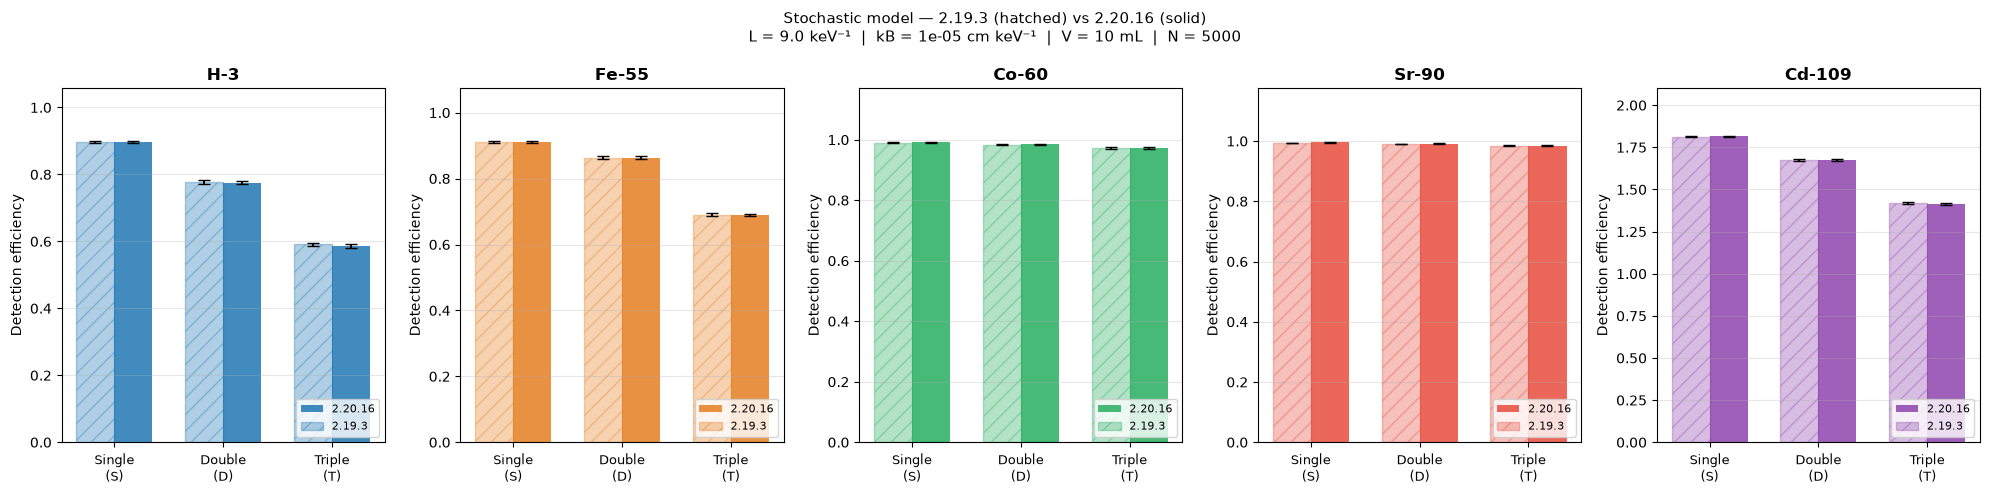

Figure saved.


In [9]:
n_nuc = len(NUCLIDES)
fig, axes = plt.subplots(1, n_nuc, figsize=(4 * n_nuc, 5))
if n_nuc == 1: axes = [axes]
fig.suptitle(
    f'Stochastic model — {VERSION_REF} (hatched) vs {VERSION_NEW} (solid)\n'
    f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
    fontsize=11)

EFF  = ['eff_S', 'eff_D', 'eff_T']
UKEY = ['u_S',   'u_D',   'u_T'  ]
XLBL = ['Single\n(S)', 'Double\n(D)', 'Triple\n(T)']
x    = np.arange(3)
w    = 0.35

for ax, rad, col in zip(axes, NUCLIDES, COLORS):
    r_ref = stoch_ref.get(rad, {})
    r_new = stoch_new.get(rad, {})

    # new version — solid bars
    if 'eff_S' in r_new:
        ax.bar(x + w/2, [r_new[k] for k in EFF], w,
               yerr=[r_new[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label=VERSION_NEW)

    # reference version — hatched bars or error box
    if 'eff_S' in r_ref:
        ax.bar(x - w/2, [r_ref[k] for k in EFF], w,
               yerr=[r_ref[k] for k in UKEY], capsize=4,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label=VERSION_REF)
    else:
        err_txt = r_ref.get('error', r_ref.get('_parse_error', '?'))
        ax.text(0.5, 0.5,
                f'v{VERSION_REF}\n{err_txt}',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=8, color='red',
                bbox=dict(boxstyle='round', fc='#fff0f0', ec='red', lw=1.5))
        ax.bar(x - w/2, [0, 0, 0], w, color=col, alpha=0.15, hatch='//',
               edgecolor=col, label=f'{VERSION_REF} — ERROR')

    ax.set_title(rad, fontsize=12, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
    ax.set_ylabel('Detection efficiency')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(axis='y', alpha=0.3)
    ymax = max((max(r_new.get(k, 0) for k in EFF) if 'eff_S' in r_new else 1), 0.05)
    ax.set_ylim(0, min(ymax * 1.18, 2.1))

plt.tight_layout()
plt.savefig(f'validation_stochastic_{VERSION_REF}_vs_{VERSION_NEW}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 6. Analytical vs Stochastic — new version only

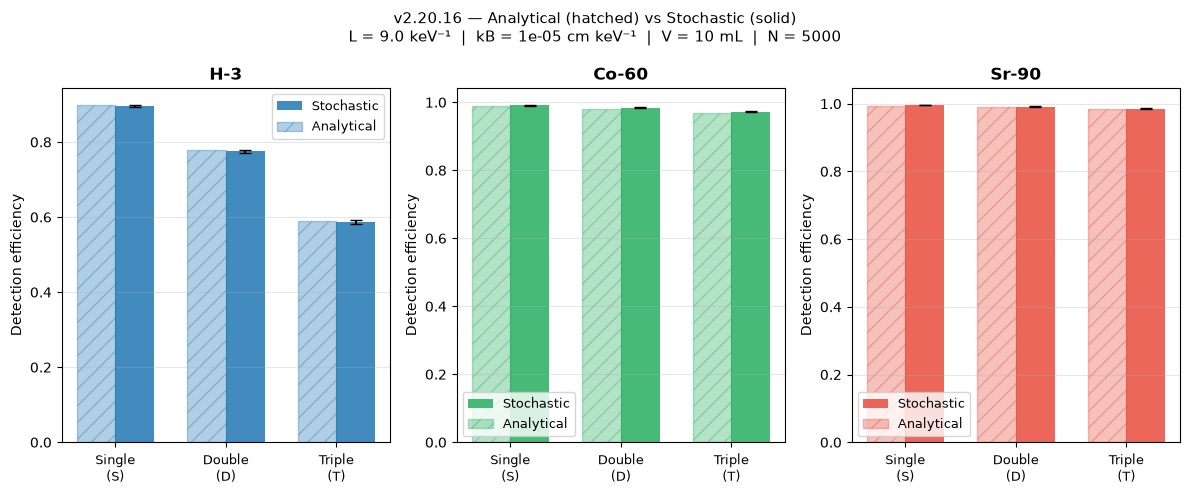

Figure saved.


In [10]:
# Only nuclides where both models are available (β emitters or have a β spectrum)
both_models = [r for r in NUCLIDES if 'eff_S' in ana_new.get(r, {}) and 'eff_S' in stoch_new.get(r, {})]

if not both_models:
    print('No nuclide with both analytical and stochastic results.')
else:
    n = len(both_models)
    fig2, axes2 = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes2 = [axes2]
    fig2.suptitle(f'v{VERSION_NEW} — Analytical (hatched) vs Stochastic (solid)\n'
                  f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
                  fontsize=11)

    for ax, rad in zip(axes2, both_models):
        col = COLORS[NUCLIDES.index(rad)]
        r_s = stoch_new[rad]
        r_a = ana_new[rad]

        ax.bar(x + w/2, [r_s[k] for k in EFF], w,
               yerr=[r_s[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label='Stochastic')
        ax.bar(x - w/2, [r_a[k] for k in EFF], w,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label='Analytical')

        ax.set_title(rad, fontsize=12, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
        ax.set_ylabel('Detection efficiency')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_analytical_vs_stochastic_{VERSION_NEW}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved.')

## 6b. Analytical vs Stochastic — reference version

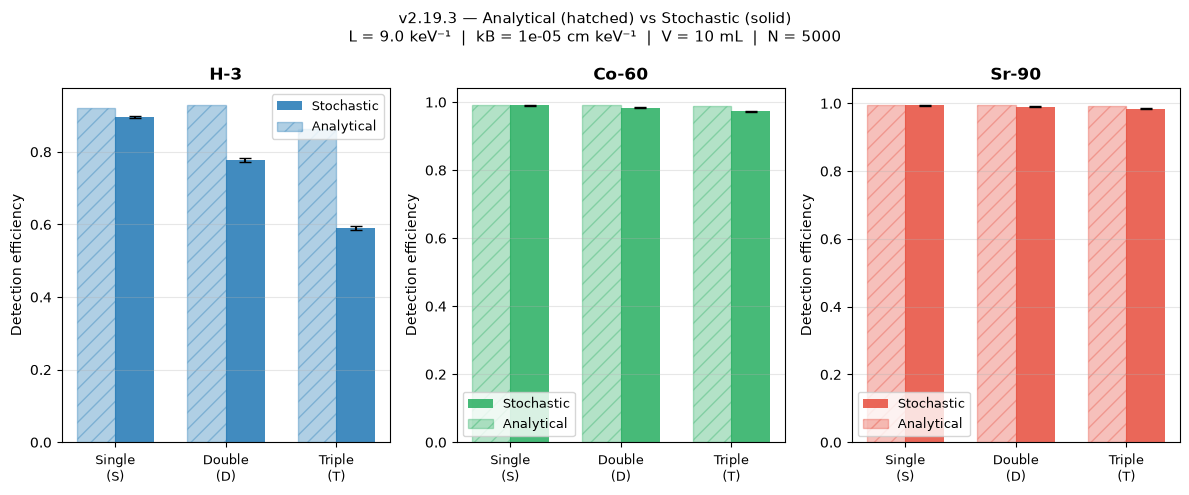

Figure saved — v2.19.3.
  Not shown (no result in ≥1 model for v2.19.3): ['Fe-55', 'Cd-109']


In [11]:
both_models_ref = [r for r in NUCLIDES
                   if 'eff_S' in ana_ref.get(r, {}) and 'eff_S' in stoch_ref.get(r, {})]

if not both_models_ref:
    print(f'No nuclide with both analytical and stochastic results for v{VERSION_REF}.')
else:
    n = len(both_models_ref)
    fig3, axes3 = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes3 = [axes3]
    fig3.suptitle(f'v{VERSION_REF} — Analytical (hatched) vs Stochastic (solid)\n'
                  f'L = {L} keV⁻¹  |  kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
                  fontsize=11)

    for ax, rad in zip(axes3, both_models_ref):
        col = COLORS[NUCLIDES.index(rad)]
        r_s = stoch_ref[rad]
        r_a = ana_ref[rad]

        ax.bar(x + w/2, [r_s[k] for k in EFF], w,
               yerr=[r_s[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label='Stochastic')
        ax.bar(x - w/2, [r_a[k] for k in EFF], w,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label='Analytical')

        ax.set_title(rad, fontsize=12, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
        ax.set_ylabel('Detection efficiency')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_analytical_vs_stochastic_{VERSION_REF}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved — v{VERSION_REF}.')
    if len(both_models_ref) < len(NUCLIDES):
        missing = [r for r in NUCLIDES if r not in both_models_ref]
        print(f'  Not shown (no result in ≥1 model for v{VERSION_REF}): {missing}')

## 7. Validation summary

In [12]:
print(f'\n══════════════════════════════════════════════════════════════════')
print(f'  FUNCTIONAL VALIDATION SUMMARY')
print(f'  Reference : {VERSION_REF}   New : {VERSION_NEW}')
print(f'  L={L} keV⁻¹  kB={kB} cm keV⁻¹  V={V} mL  N={N}')
print(f'══════════════════════════════════════════════════════════════════')
print(f'{"Nuclide":<10}  {"Analytical":^24}  {"Stochastic":^24}')
print(f'{"":10}  {VERSION_REF:^11} {VERSION_NEW:^11}  {VERSION_REF:^11} {VERSION_NEW:^11}')
print(f'──────────────────────────────────────────────────────────────────')

all_pass = True
for rad in NUCLIDES:
    sym_a_ref, _ = status(ana_ref.get(rad, {}))
    sym_a_new, _ = status(ana_new.get(rad, {}))
    sym_s_ref, _ = status(stoch_ref.get(rad, {}))
    sym_s_new, _ = status(stoch_new.get(rad, {}))
    print(f'{rad:<10}  {sym_a_ref:^11} {sym_a_new:^11}  {sym_s_ref:^11} {sym_s_new:^11}')
    if sym_s_new == '✗':
        all_pass = False

print(f'══════════════════════════════════════════════════════════════════')
print(f'  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)')
verdict = '  ✅ PASSED' if all_pass else '  ❌ FAILED — see ✗ entries above'
print(f'  Stochastic {VERSION_NEW}: {verdict}')
print(f'══════════════════════════════════════════════════════════════════')


══════════════════════════════════════════════════════════════════
  FUNCTIONAL VALIDATION SUMMARY
  Reference : 2.19.3   New : 2.20.16
  L=9.0 keV⁻¹  kB=1e-05 cm keV⁻¹  V=10 mL  N=5000
══════════════════════════════════════════════════════════════════
Nuclide            Analytical                Stochastic       
              2.19.3      2.20.16      2.19.3      2.20.16  
──────────────────────────────────────────────────────────────────
H-3              ✓           ✓            ✓           ✓     
Fe-55            ✗           ✗            ✓           ✓     
Co-60            ✓           ✓            ✓           ✓     
Sr-90            ✓           ✓            ✓           ✓     
Cd-109           ✗           ✗            ✓           ✓     
══════════════════════════════════════════════════════════════════
  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)
  Stochastic 2.20.16:   ✅ PASSED
══════════════════════════════════════════════════════════════════


## 8. Inverse problem — `eff()` / `effA()` at a fixed TDCR

Sections 3–7 solve the **forward problem**: given a fixed free parameter `L`,
compute the resulting TDCR efficiencies (`modelAnalytical` / `TDCRPy`).

This section solves the **inverse problem** that a real TDCR measurement
poses: given a *measured* TDCR ratio `T/D = TD_TARGET`, recover the free
parameter `L` and the efficiencies that reproduce it.

- `tm.eff(TD, ...)` — stochastic inversion (MC + bounded/Nelder–Mead optimiser).
- `tm.effA(TD, ...)` — analytical inversion, much faster but only valid for
  (quasi-)pure β emitters — same restriction observed in section 3
  (N/A for Fe-55, Cd-109; approximate for Co-60).

In [13]:
def make_effA_script():
    """Return a Python script that runs effA (analytical inversion) for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCRPy as tm
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        L0, L_opt, eff_S, eff_D, eff_T = tm.effA({TD_TARGET}, rad, '1', {kB}, {V})
        results[rad] = {{'L0': float(L0), 'eff_S': float(eff_S),
                         'eff_D': float(eff_D), 'eff_T': float(eff_T)}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:120]}}
print(json.dumps(results))
"""

def make_eff_script():
    """Return a Python script that runs eff (stochastic inversion) for all NUCLIDES."""
    return f"""
import json
import tdcrpy.TDCRPy as tm
nuclides = {NUCLIDES!r}
results = {{}}
for rad in nuclides:
    try:
        out = tm.eff({TD_TARGET}, rad, '1', {kB}, {V}, N={N})
        results[rad] = {{'L0': float(out[0]),
                         'eff_S': float(out[2]), 'u_S': float(out[3]),
                         'eff_D': float(out[4]), 'u_D': float(out[5]),
                         'eff_T': float(out[6]), 'u_T': float(out[7])}}
    except Exception as e:
        results[rad] = {{'error': type(e).__name__, 'msg': str(e)[:200]}}
print(json.dumps(results))
"""

print('Inverse-problem script builders defined.')

Inverse-problem script builders defined.


### 8a. Analytical inversion — `effA()`

In [14]:
script_effA = make_effA_script()

print(f'Running effA() — {VERSION_REF} ...')
effA_ref = parse(*run_ref(script_effA))

print(f'Running effA() — {VERSION_NEW} ...')
effA_new = {}
for rad in NUCLIDES:
    try:
        L0, L_opt, eff_S, eff_D, eff_T = tm.effA(TD_TARGET, rad, '1', kB, V)
        effA_new[rad] = {'L0': float(L0), 'eff_S': float(eff_S),
                          'eff_D': float(eff_D), 'eff_T': float(eff_T)}
    except Exception as e:
        effA_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:120]}

print('Done.')

HDR3 = f'{"Nuclide":<10} {"Version":<10} {"L0":>8} {"eff_S":>9} {"eff_D":>9} {"eff_T":>9}  Note'
print(f'\n── effA() — inversion at T/D = {TD_TARGET} ────────────────────────────────────')
print(HDR3); print('─' * 78)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, effA_ref), (VERSION_NEW, effA_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            note = ('N/A — EC, no β spectrum' if rad in ('Fe-55', 'Cd-109')
                    else 'approx. (β-spectrum only)' if rad == 'Co-60' else 'valid')
            print(f'{rad:<10} {ver:<10} {row["L0"]:>8.4f} {row["eff_S"]:>9.5f} '
                  f'{row["eff_D"]:>9.5f} {row["eff_T"]:>9.5f}  {sym} {note}')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:50]
            print(f'{rad:<10} {ver:<10} {" ":>8} {" ":>9} {" ":>9} {" ":>9}  {sym} {row.get("error","ERR")}: {msg}')
    print()

Running effA() — 2.19.3 ...


Running effA() — 2.20.16 ...


Done.

── effA() — inversion at T/D = 0.75 ────────────────────────────────────
Nuclide    Version          L0     eff_S     eff_D     eff_T  Note
──────────────────────────────────────────────────────────────────────────────
H-3        2.19.3       2.1661   0.57853   0.77137   0.57853  ✓ valid
H-3        2.20.16      8.6506   0.89528   0.77138   0.57853  ✓ valid

Fe-55      2.19.3                                             ✗ UnboundLocalError: cannot access local variable 'file_path' where it 
Fe-55      2.20.16                                            ✗ ValueError: No pre-computed beta spectrum for 'Fe-55'. Availab

Co-60      2.19.3       0.1007   0.63269   0.80804   0.63269  ✓ approx. (β-spectrum only)
Co-60      2.20.16      0.3484   0.90002   0.78265   0.58699  ✓ approx. (β-spectrum only)

Sr-90      2.19.3       0.1007   0.81520   0.90633   0.81520  ✓ valid
Sr-90      2.20.16      0.1631   0.90860   0.79545   0.59654  ✓ valid

Cd-109     2.19.3                                

### 8b. Stochastic inversion — `eff()`

In [15]:
script_eff = make_eff_script()

print(f'Running eff() — {VERSION_REF}  (N={N}, may take several minutes) ...')
eff_ref = parse(*run_ref(script_eff, timeout=900))
print(f'  → {[k for k in eff_ref if not k.startswith("_")]}')

print(f'Running eff() — {VERSION_NEW} ...')
eff_new = {}
for rad in NUCLIDES:
    try:
        out = tm.eff(TD_TARGET, rad, '1', kB, V, N=N)
        eff_new[rad] = {'L0': float(out[0]),
                         'eff_S': float(out[2]), 'u_S': float(out[3]),
                         'eff_D': float(out[4]), 'u_D': float(out[5]),
                         'eff_T': float(out[6]), 'u_T': float(out[7])}
    except Exception as e:
        eff_new[rad] = {'error': type(e).__name__, 'msg': str(e)[:200]}

print('Done.')

HDR4 = (f'{"Nuclide":<10} {"Version":<10} {"L0":>8}'
        f' {"eff_S":>9} {"±":>7} {"eff_D":>9} {"±":>7} {"eff_T":>9} {"±":>7}  Status')
print(f'\n── eff() — inversion at T/D = {TD_TARGET} ─────────────────────────────────────────────────')
print(HDR4); print('─' * 96)
for rad in NUCLIDES:
    for ver, res in [(VERSION_REF, eff_ref), (VERSION_NEW, eff_new)]:
        row = res.get(rad, {})
        sym, _ = status(row)
        if 'eff_S' in row:
            print(f'{rad:<10} {ver:<10} {row["L0"]:>8.4f}'
                  f' {row["eff_S"]:>9.5f} {row["u_S"]:>7.5f}'
                  f' {row["eff_D"]:>9.5f} {row["u_D"]:>7.5f}'
                  f' {row["eff_T"]:>9.5f} {row["u_T"]:>7.5f}  {sym} OK')
        else:
            msg = row.get('msg', row.get('_parse_error', '?'))[:60]
            print(f'{rad:<10} {ver:<10} {" ":>8}'
                  f' {" ":>9} {" ":>7} {" ":>9} {" ":>7} {" ":>9} {" ":>7}'
                  f'  {sym} {row.get("error","ERR")}: {msg}')
    print()

Running eff() — 2.19.3  (N=5000, may take several minutes) ...


  → []
Running eff() — 2.20.16 ...


Done.

── eff() — inversion at T/D = 0.75 ─────────────────────────────────────────────────
Nuclide    Version          L0     eff_S       ±     eff_D       ±     eff_T       ±  Status
────────────────────────────────────────────────────────────────────────────────────────────────
H-3        2.19.3                                                                     — ERR: ?
H-3        2.20.16      9.0603   0.89911 0.00301   0.77573 0.00450   0.58180 0.00520  ✓ OK

Fe-55      2.19.3                                                                     — ERR: ?
Fe-55      2.20.16     66.0641   0.99469 0.00048   0.97019 0.00127   0.92355 0.00314  ✓ OK

Co-60      2.19.3                                                                     — ERR: ?
Co-60      2.20.16      0.2994   0.89481 0.00314   0.77336 0.00455   0.58002 0.00520  ✓ OK

Sr-90      2.19.3                                                                     — ERR: ?
Sr-90      2.20.16      0.1632   0.91157 0.00289   0.80021 0.0

### 8c. Comparison plot — `effA()` vs `eff()` (new version)

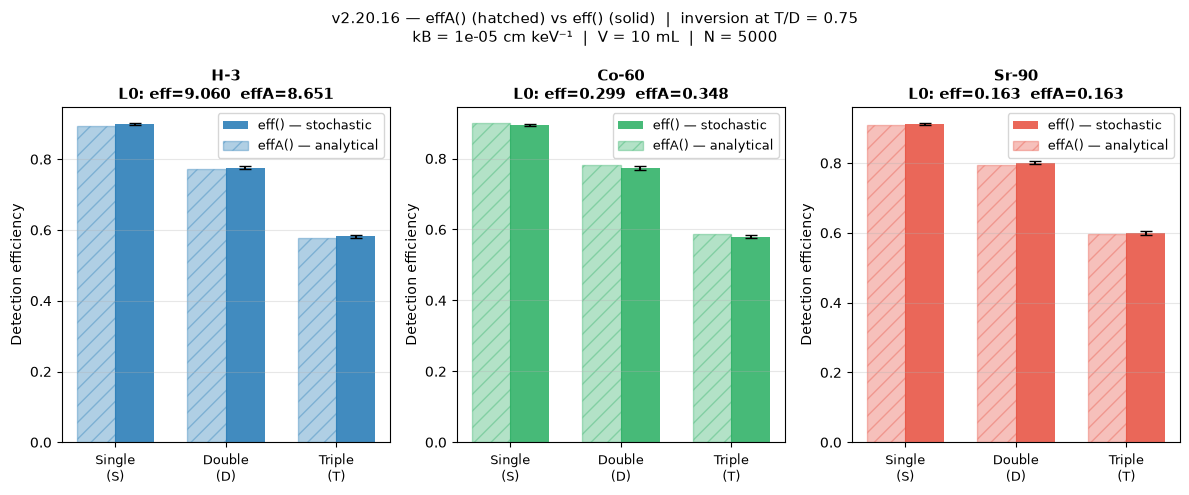

Figure saved.
  Not shown (effA() N/A or eff() error for v2.20.16): ['Fe-55', 'Cd-109']


In [16]:
# Only nuclides where both inversion methods succeeded (β emitters or have a β spectrum)
both_inv_new = [r for r in NUCLIDES if 'eff_S' in effA_new.get(r, {}) and 'eff_S' in eff_new.get(r, {})]

if not both_inv_new:
    print('No nuclide with both effA() and eff() results.')
else:
    n = len(both_inv_new)
    fig4, axes4 = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1: axes4 = [axes4]
    fig4.suptitle(f'v{VERSION_NEW} — effA() (hatched) vs eff() (solid)  |  inversion at T/D = {TD_TARGET}\n'
                  f'kB = {kB} cm keV⁻¹  |  V = {V} mL  |  N = {N}',
                  fontsize=11)

    for ax, rad in zip(axes4, both_inv_new):
        col = COLORS[NUCLIDES.index(rad)]
        r_s = eff_new[rad]
        r_a = effA_new[rad]

        ax.bar(x + w/2, [r_s[k] for k in EFF], w,
               yerr=[r_s[k] for k in UKEY], capsize=4,
               color=col, alpha=0.85, label='eff() — stochastic')
        ax.bar(x - w/2, [r_a[k] for k in EFF], w,
               color=col, alpha=0.35, hatch='//', edgecolor=col, label='effA() — analytical')

        ax.set_title(f'{rad}\nL0: eff={r_s["L0"]:.3f}  effA={r_a["L0"]:.3f}',
                     fontsize=11, fontweight='bold')
        ax.set_xticks(x); ax.set_xticklabels(XLBL, fontsize=9)
        ax.set_ylabel('Detection efficiency')
        ax.legend(fontsize=9)
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'validation_effA_vs_eff_{VERSION_NEW}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print('Figure saved.')
    if len(both_inv_new) < len(NUCLIDES):
        missing = [r for r in NUCLIDES if r not in both_inv_new]
        print(f'  Not shown (effA() N/A or eff() error for v{VERSION_NEW}): {missing}')

## 9. Inverse validation summary

In [17]:
print(f'\n══════════════════════════════════════════════════════════════════')
print(f'  INVERSE VALIDATION SUMMARY (eff() / effA())')
print(f'  Reference : {VERSION_REF}   New : {VERSION_NEW}')
print(f'  T/D={TD_TARGET}  kB={kB} cm keV⁻¹  V={V} mL  N={N}')
print(f'══════════════════════════════════════════════════════════════════')
print(f'{"Nuclide":<10}  {"effA()":^24}  {"eff()":^24}')
print(f'{"":10}  {VERSION_REF:^11} {VERSION_NEW:^11}  {VERSION_REF:^11} {VERSION_NEW:^11}')
print(f'──────────────────────────────────────────────────────────────────')

all_pass_inv = True
for rad in NUCLIDES:
    sym_a_ref, _ = status(effA_ref.get(rad, {}))
    sym_a_new, _ = status(effA_new.get(rad, {}))
    sym_s_ref, _ = status(eff_ref.get(rad, {}))
    sym_s_new, _ = status(eff_new.get(rad, {}))
    print(f'{rad:<10}  {sym_a_ref:^11} {sym_a_new:^11}  {sym_s_ref:^11} {sym_s_new:^11}')
    if sym_s_new == '✗':
        all_pass_inv = False

print(f'══════════════════════════════════════════════════════════════════')
print(f'  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)')
verdict_inv = '  ✅ PASSED' if all_pass_inv else '  ❌ FAILED — see ✗ entries above'
print(f'  eff() {VERSION_NEW}: {verdict_inv}')
print(f'══════════════════════════════════════════════════════════════════')


══════════════════════════════════════════════════════════════════
  INVERSE VALIDATION SUMMARY (eff() / effA())
  Reference : 2.19.3   New : 2.20.16
  T/D=0.75  kB=1e-05 cm keV⁻¹  V=10 mL  N=5000
══════════════════════════════════════════════════════════════════
Nuclide              effA()                    eff()          
              2.19.3      2.20.16      2.19.3      2.20.16  
──────────────────────────────────────────────────────────────────
H-3              ✓           ✓            —           ✓     
Fe-55            ✗           ✗            —           ✓     
Co-60            ✓           ✓            —           ✓     
Sr-90            ✓           ✓            —           ✓     
Cd-109           ✗           ✗            —           ✓     
══════════════════════════════════════════════════════════════════
  ✓ = OK   ✗ = error   — = N/A (no β spectrum for this model)
  eff() 2.20.16:   ✅ PASSED
══════════════════════════════════════════════════════════════════
